### Introduction to musicology

In [54]:
import pandas as pd
from fractions import Fraction
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

### Read tsv file

In [57]:
path = "/Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/jazz_transcriptions/notes/Summertime - Chet Baker.tsv"
df = pd.read_csv(path, sep='\t')
df

,mc,mn,mc_onset,mn_onset,timesig,staff,voice,duration,gracenote,nominal_duration,scalar,tied,tpc,midi,volta,chord_id
0,1,0,1/8,5/8,4/4,1,1,1/4,NaN,1/4,1,NaN,5,71,NaN,0
1,1,0,3/8,7/8,4/4,1,1,1/8,NaN,1/8,1,NaN,1,67,NaN,1
2,2,1,0,0,4/4,1,1,1,NaN,1,1,NaN,5,71,NaN,2
3,3,2,1/8,1/8,4/4,1,1,1/4,NaN,1/4,1,NaN,3,69,NaN,3
4,3,2,3/8,3/8,4/4,1,1,1/8,NaN,1/8,1,NaN,1,67,NaN,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
482,153,152,7/8,7/8,4/4,1,1,1/8,NaN,1/8,1,NaN,6,78,NaN,482
483,154,153,0,0,2/4,1,1,3/8,NaN,1/4,3/2,NaN,3,81,NaN,483
484,154,153,3/8,3/8,2/4,1,1,1/16,NaN,1/16,1,NaN,-4,80,NaN,484
485,154,153,7/16,7/16,2/4,1,1,1/16,NaN,1/16,1,NaN,1,79,NaN,485


In [59]:
pitch_class_names = ['C', 'C#', 'D', 'D#', 'E', 'F', 
                     'F#', 'G', 'G#', 'A', 'A#', 'B']

df['pc'] = df['midi'] % 12
df['note'] = df['pc'].map(lambda x: pitch_class_names[x])

df['mc_onset_float'] = df['mc_onset'].apply(lambda x: float(Fraction(x)))
df['order'] = df['mc'] + df['mc_onset_float']

df

,mc,mn,mc_onset,mn_onset,timesig,staff,voice,duration,gracenote,nominal_duration,scalar,tied,tpc,midi,volta,chord_id,pc,note,mc_onset_float,order
0,1,0,1/8,5/8,4/4,1,1,1/4,NaN,1/4,1,NaN,5,71,NaN,0,11,B,0.1250,1.1250
1,1,0,3/8,7/8,4/4,1,1,1/8,NaN,1/8,1,NaN,1,67,NaN,1,7,G,0.3750,1.3750
2,2,1,0,0,4/4,1,1,1,NaN,1,1,NaN,5,71,NaN,2,11,B,0.0000,2.0000
3,3,2,1/8,1/8,4/4,1,1,1/4,NaN,1/4,1,NaN,3,69,NaN,3,9,A,0.1250,3.1250
4,3,2,3/8,3/8,4/4,1,1,1/8,NaN,1/8,1,NaN,1,67,NaN,4,7,G,0.3750,3.3750
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
482,153,152,7/8,7/8,4/4,1,1,1/8,NaN,1/8,1,NaN,6,78,NaN,482,6,F#,0.8750,153.8750
483,154,153,0,0,2/4,1,1,3/8,NaN,1/4,3/2,NaN,3,81,NaN,483,9,A,0.0000,154.0000
484,154,153,3/8,3/8,2/4,1,1,1/16,NaN,1/16,1,NaN,-4,80,NaN,484,8,G#,0.3750,154.3750
485,154,153,7/16,7/16,2/4,1,1,1/16,NaN,1/16,1,NaN,1,79,NaN,485,7,G,0.4375,154.4375


### Plot midi vs measure

In [79]:
pitchclass = df.copy()
pitchclass = df.groupby('order')[['note', 'pc']].agg(list).reset_index()
pitchclass

,order,note,pc
0,1.1250,[B],[11]
1,1.3750,[G],[7]
2,2.0000,[B],[11]
3,3.1250,[A],[9]
4,3.3750,[G],[7]
...,...,...,...
479,153.8750,[F#],[6]
480,154.0000,[A],[9]
481,154.3750,[G#],[8]
482,154.4375,[G],[7]


The history saving thread hit an unexpected error (OperationalError('unable to open database file')).History will not be written to the database.


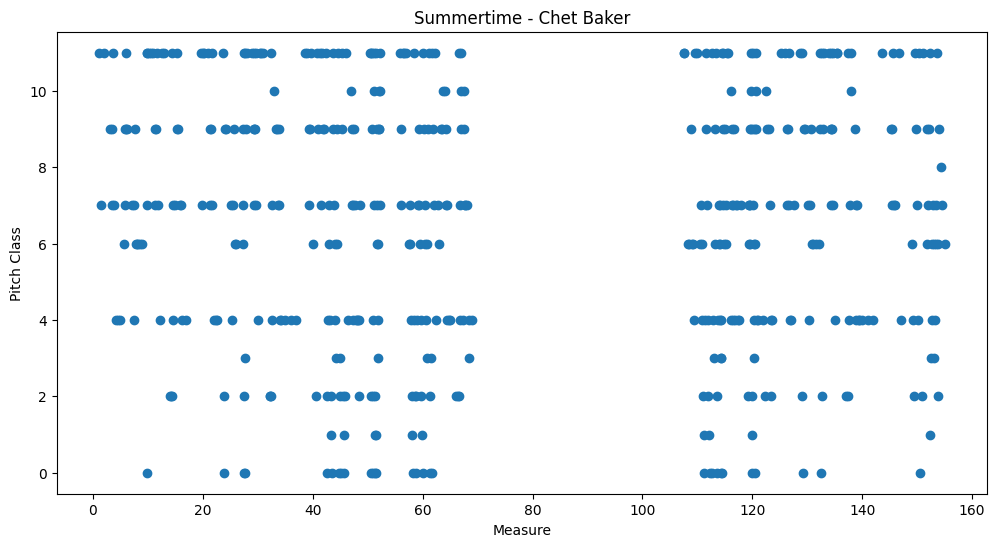

In [81]:
x = df['order']
y = df['pc']

plt.figure(figsize=(12, 6))
plt.scatter(x,y)
plt.xlabel('Measure')
plt.ylabel('Pitch Class')
plt.title("Summertime - Chet Baker")
plt.show()

### Plot note count

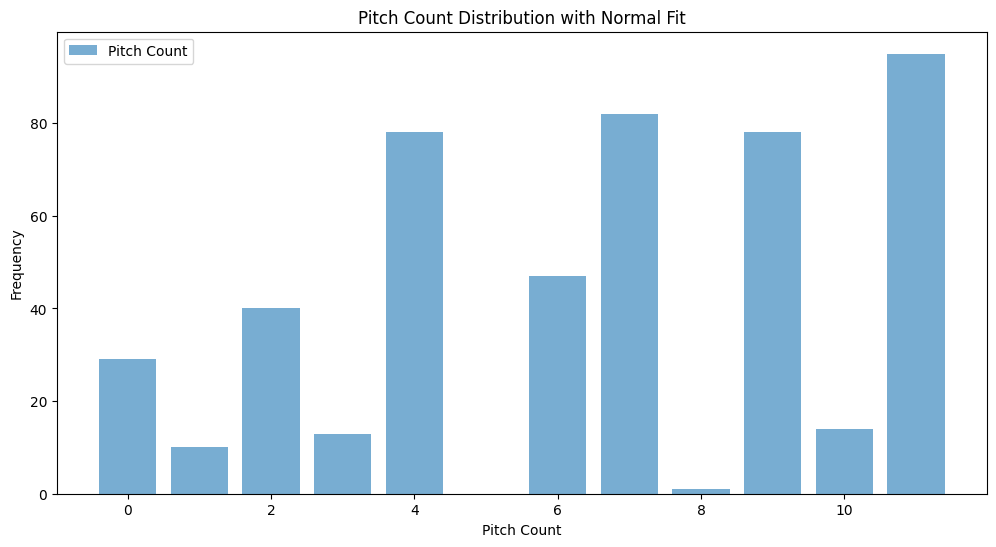

In [103]:
note_counts = df['pc'].value_counts().sort_index()

mu = df['pc'].mean()

x = np.linspace(pc_counts.index.min(), pc_counts.index.max(), 12)

plt.figure(figsize=(12, 6))
plt.bar(pc_counts.index, pc_counts.values, width=0.8, alpha=0.6, label='Pitch Count')

# Labels
plt.title('Pitch Count Distribution with Normal Fit')
plt.xlabel('Pitch Count')
plt.ylabel('Frequency')
plt.legend()

# Show
plt.show()

In [105]:
pitch_class_names[round(mu)] 

'G'

In [23]:
path = "/Users/Jessica/Documents/ERIP2025/jazz_transcriptions/metadata.tsv"
metadata = pd.read_csv(path, sep='\t')
metadata[metadata['fnames'].str.contains('summertime', case=False, na=False)]

,rel_paths,fnames,last_mc,last_mn,KeySig,TimeSig,label_count,annotated_key,composer,workTitle,...,staff_7_ambitus,staff_7_instrument,staff_8_ambitus,staff_8_instrument,staff_9_ambitus,staff_9_instrument,transcribed_instruments,transcribed_sections,transposition,year_certain
92,by_Carles_Margarit,Summertime - Chet Baker,155,154,1: 1,"1: 4/4, 154: 2/4, 155: 4/4",137,NaN,George Gershwin,Summertime,...,NaN,NaN,NaN,NaN,NaN,NaN,tp,solo,Bb,1
93,by_Carles_Margarit,Summertime - Chet Baker (Concert Key),155,154,1: -1,"1: 4/4, 154: 2/4, 155: 4/4",137,NaN,George Gershwin,Summertime,...,NaN,NaN,NaN,NaN,NaN,NaN,tp,solo,Concert Key,1


Average pitch class: G, which aligns with the piece's key of either G major or E minor.